In [1]:
import os

os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

# os.environ["HF_HOME"] = "/mnt/data/yizhenyu/hf_cache"
# os.environ["HUGGINGFACE_HUB_CACHE"] = os.path.join(os.environ["HF_HOME"], "hub")
# os.environ["TRANSFORMERS_CACHE"] = os.path.join(os.environ["HF_HOME"], "transformers")
# os.environ["HF_HUB_OFFLINE"] = "1"
# os.environ["TRANSFORMERS_OFFLINE"] = "1"

In [100]:
import argparse
import datetime
import json
import numpy as np

import time
from pathlib import Path
import time
import torch

import timm
import open_clip

import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import sys

PROJECT_ROOT = "/mnt/data/yizhenyu/data/Endomaster/workspace/VLP/EndoVLP"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from transformers import CLIPProcessor, CLIPModel, CLIPVisionModel

In [257]:
mode = 'clip' 
# mode = 'biomedclip'

if mode == 'clip':
    # model_open_clip, _, _ = open_clip.create_model_and_transforms('ViT-B-16', pretrained='openai')
    tokenizer = open_clip.get_tokenizer('ViT-B-16')
    model_open_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
elif mode == 'biomedclip':
    model_id = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
    cache_dir = "/mnt/data/yizhenyu/hf_cache/hub"
    model_open_clip, _ = open_clip.create_model_from_pretrained(model_id, cache_dir=cache_dir)
    tokenizer = open_clip.get_tokenizer(model_id)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_open_clip.to(device)
model_open_clip.eval()
print('done')

done


In [259]:
testsize = 224

def get_transform(testsize=224):
    return transforms.Compose([
        transforms.Resize((testsize, testsize)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

transform = get_transform(testsize)

def process_data(image_groups, text_list=None, transform=None, tokenizer=None, stack=False):
    """
    Args:
        image_groups: List[List[str]], 每个子列表是一个样本的多张图路径
        text_list: List[str], 每个样本对应的全局描述文本
    """
    all_imgs = []
    image_counts = []

    for group in image_groups:
        group_imgs = []
        for p in group:
            if isinstance(p, str):
                img = Image.open(p)
            else:
                img = p
            if tokenizer is not None:
                img = img.convert('RGB')
                img = transform(img)
            group_imgs.append(img)
        image_counts.append(len(group))
        if tokenizer is not None:
            group_imgs = torch.stack(group_imgs)
        all_imgs.append(group_imgs)
 
    # 处理文本 (Full Text)
    if text_list is not None and tokenizer is not None:
        texts_tokenized = tokenizer(text_list)
    else:
        texts_tokenized = None
    return all_imgs, texts_tokenized, image_counts



In [190]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
from sklearn.preprocessing import LabelBinarizer
import random

def visualize_similarity_with_metrics(similarity_matrix, image_labels, text_labels, title="Endoscopy Site Retrieval Evaluation"):
    """
    Args:
        similarity_matrix: [N_samples, M_classes] 图像与文本的原始相似度得分
        image_labels: 长度为 N 的列表，包含每张图的真实标签字符串
        text_labels: 长度为 M 的列表，包含所有候选类别的名称
    """
    # 1. 数据转换与概率计算
    if torch.is_tensor(similarity_matrix):
        sim_np = similarity_matrix.cpu().detach().numpy()
    else:
        sim_np = similarity_matrix

    # 简单归一化防止指数溢出
    if np.max(sim_np) > 50:
        sim_np = sim_np / (np.max(sim_np) / 10.0)
    
    # 计算 Softmax 概率
    exp_sim = np.exp(sim_np)
    probs = exp_sim / np.sum(exp_sim, axis=1, keepdims=True)
    
    # 标签转索引
    label_to_idx = {name: i for i, name in enumerate(text_labels)}
    y_true = np.array([label_to_idx[l] for l in image_labels])
    y_pred = np.argmax(probs, axis=1)
    
    # 2. 计算全局指标
    acc_global = accuracy_score(y_true, y_pred)
    lb = LabelBinarizer()
    lb.fit(range(len(text_labels)))
    y_true_bin = lb.transform(y_true)
    
    try:
        auc_global = roc_auc_score(y_true_bin, probs, multi_class='ovr', average='macro')
    except:
        auc_global = 0.0

    # 3. 计算每个类别的 ACC (Recall) 和 AUC
    per_class_metrics = {}
    print("\n" + "="*50)
    print(f"{'Class Name':<20} | {'ACC (Recall)':<12} | {'AUC (OvR)':<10}")
    print("-" * 50)
    
    for i, class_name in enumerate(text_labels):
        # 该类的真实掩码
        idx = (y_true == i)
        
        # 计算该类 ACC (即 Recall: 该类对的占该类总数的比例)
        if np.sum(idx) > 0:
            # 只有在样本中存在该类时才计算
            cls_acc = recall_score(y_true == i, y_pred == i, zero_division=0)
            
            # 计算该类 AUC (One-vs-Rest)
            try:
                cls_auc = roc_auc_score(y_true_bin[:, i], probs[:, i])
            except:
                cls_auc = 0.0
        else:
            cls_acc, cls_auc = 0.0, 0.0
            
        per_class_metrics[class_name] = {"acc": cls_acc, "auc": cls_auc}
        print(f"{class_name:<20} | {cls_acc:<12.4f} | {cls_auc:<10.4f}")
    name_total = 'total'
    print(f"{name_total:<20} | {acc_global:<12.4f} | {auc_global:<10.4f}")
    print("="*50)

    # 4. 随机选取 10 个例子进行可视化
    num_samples = len(image_labels)
    display_num = min(10, num_samples)
    # 随机采样索引
    random_indices = np.random.choice(range(num_samples), display_num, replace=False)
    
    # 提取采样数据
    selected_probs = probs[random_indices]
    selected_labels = [image_labels[i] for i in random_indices]
    
    # 转置用于绘图：Y轴为文本类别，X轴为随机选取的图像样本
    plot_data = selected_probs.transpose(1, 0)
    
    # 5. 绘图
    plt.figure(figsize=(max(8, display_num * 1.5), len(text_labels) * 1.0))
    
    metrics_str = f"Global ACC: {acc_global:.4f}  Global AUC: {auc_global:.4f}"
    
    ax = sns.heatmap(plot_data, 
                xticklabels=selected_labels, 
                yticklabels=text_labels, 
                annot=True,       
                fmt=".2f",        
                cmap='viridis',     
                annot_kws={"size": 12, "weight": "bold"}, 
                cbar_kws={'label': 'Probability Score'})

    plt.title(f"{title}\n{metrics_str}\n(Randomly sampled {display_num} examples)", fontsize=16, pad=20)
    plt.xlabel("Ground Truth Labels (Sampled Images)", fontsize=12)
    plt.ylabel("Candidate Site Prompts", fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

    return acc_global, auc_global, per_class_metrics


In [81]:
import os
import random
from pathlib import Path
base_dir = '/mnt/data/yizhenyu/data/Endomaster/dataset/hyper_kvasir/hyper-kvasir/labeled-images/'

def get_random_endoscopy_samples(base_path, num_per_class=2, mode='both', seed=None, get_all=False):
    """
    从内镜文件夹中随机选取图片路径，支持按消化道区域过滤。
    
    Args:
        base_path: Hyper-Kvasir 标注图像的根目录 ('.../labeled-images/')
        num_per_class: 每个解剖部位随机抽取的图片数量
        mode: 'upper' (仅上), 'lower' (仅下), 'both' (全部)
        seed: 随机种子
    
    Returns:
        sample_image_paths: List[List[str]], 例如 [['path1'], ['path2'], ...]
    """
    if seed is not None:
        random.seed(seed)
        
    # 定义完整结构
    structure = {
        "lower-gi-tract": ["cecum", "ileum", "retroflex-rectum"],
        "upper-gi-tract": ["pylorus", "retroflex-stomach", "z-line"]
    }
    
    # 根据 mode 确定要遍历的 tract
    if mode == 'upper':
        tracts_to_process = ["upper-gi-tract"]
    elif mode == 'lower':
        tracts_to_process = ["lower-gi-tract"]
    elif mode == 'both':
        tracts_to_process = ["lower-gi-tract", "upper-gi-tract"]
    else:
        raise ValueError("mode 参数必须是 'upper', 'lower' 或 'both'")
    
    all_selected_paths = []
    
    for tract in tracts_to_process:
        categories = structure[tract]
        for cat in categories:
            # 构建完整路径
            cat_dir = Path(base_path) / tract / "anatomical-landmarks" / cat
            
            if not cat_dir.exists():
                print(f"跳过：文件夹不存在 {cat_dir}")
                continue
            
            # 查找 jpg 和 jpeg 图片
            images = list(cat_dir.glob("*.jpg")) + list(cat_dir.glob("*.jpeg"))
            
            if not images:
                print(f"警告: 类别 '{cat}' 下没有找到图片")
                continue
                
            # 随机采样数量控制
            if get_all:
                selected = images
            else:
                actual_num = min(len(images), num_per_class)
                selected = random.sample(images, actual_num)
            
            # 封装为 [[path1], [path2], ...]
            for img_path in selected:
                all_selected_paths.append([str(img_path)])
    
    # 随机打乱列表顺序，避免同类图片连续排列
    random.shuffle(all_selected_paths)
    
    print(f"已从 {mode} 消化道路径中选取了 {len(all_selected_paths)} 个样本。")
    return all_selected_paths

In [17]:
# %% [markdown]
# ### 针对部位检索的文本准备

# 1. 定义部位标签
# class_names = [
#     "esophagus", "z-line", "cardia", "fundus", "gastric body", "angulus", "antrum", 
#     "pylorus", "duodenum", "ileum", "cecum", "ileocecal region", "ascending colon", 
#     "hepatic flexure", "transverse colon", "splenic flexure", "descending colon", 
#     "sigmoid colon", "rectum", "retroflexion-rectum", "retroflexion-stomach"
# ]
class_names = [
    "z-line", "ileum", "cecum", "retroflexion-rectum", "retroflexion-stomach", "pylorus",
]

# 2. 构建 Prompt (使用模版增强特征)
def build_prompts(names):
    prompts = []
    for name in names:
        if 'retroflexion' in name:
            prompts.append(f"A {name.replace('-', ' view of the ')}.")
        elif name == 'z-line':
            prompts.append("An endoscopic image of the esophagus.")
        else:
            prompts.append(f"An endoscopic image of the {name}.")
    return prompts

site_prompts = build_prompts(class_names)


In [246]:
# in retroflexion mode.
# site_prompts_dict = {
#     "ileum": "An image of the ileum.",
#     "cecum": "An image of the cecum.",
#     "retroflex-rectum": "An image of the rectum",
# }
# site_prompts_dict = {
#     "ileum": "An image of the terminal ileum.",
#     "cecum": "An image of the cecum.",
#     "retroflex-rectum": "An image of the bottom of the colon",
# }
site_prompts_dict = {
    "ileum": "An image of the terminal ileum during colonoscopy.",
    "cecum": "An image of the cecum during colonoscopy.",
    "retroflex-rectum": "A medical image of the rectum during colonoscopy.", 
}
# site_prompts_dict = {
#     "ileum": "ileum",
#     "cecum": "cecum",
#     "retroflex-rectum": "rectum",
# }
# site_prompts_dict = {
#     "ileum": "A medical image of ileum mucosa.",
#     "cecum": "A medical image of cecum mucosa.",
#     "retroflex-rectum": "A medical image of rectum mucosa.",
# }

# site_prompts_dict = text_prompts = {
#     "ileum": "An endoscopy image of the terminal ileum showing small bowel mucosa with villi and lymphoid follicles.",
#     "cecum": "An endoscopy image of the cecum showing the appendiceal orifice and the tri-radiate fold of the cecum.",
#     "retroflex-rectum": "An image of rectum",
# }
# 强调判别性标志物
# site_prompts_dict = {
#     "cecum": (
#         "This is a colonoscopy report. Insertion: The colonoscope was advanced smoothly to the cecum. "
#         "The appendiceal orifice and the tri-radiate confluence of the colonic bands (crow's foot appearance) are clearly visible."
#     ),
#     "ileum": "An image of the terminal ileum.",
#     "retroflex-rectum": (
#         "This is a colonoscopy report. Rectum in retroflexion: The black shaft of the endoscope is visible, "
#         "performing a U-turn to observe the rectal cardia and anal verge."
#     )
# }

class_names_lower = [k for k in site_prompts_dict]
site_prompts_lower = [site_prompts_dict[k] for k in site_prompts_dict]
sample_image_lower = get_random_endoscopy_samples(base_dir, num_per_class=3, mode='lower', seed=42, get_all=True)

已从 lower 消化道路径中选取了 1409 个样本。


clip

Class Name           | ACC (Recall) | AUC (OvR) 
--------------------------------------------------
ileum                | 0.8889       | 0.4199    
cecum                | 0.0069       | 0.3935    
retroflex-rectum     | 0.0000       | 0.2701    
total                | 0.0106       | 0.3612    


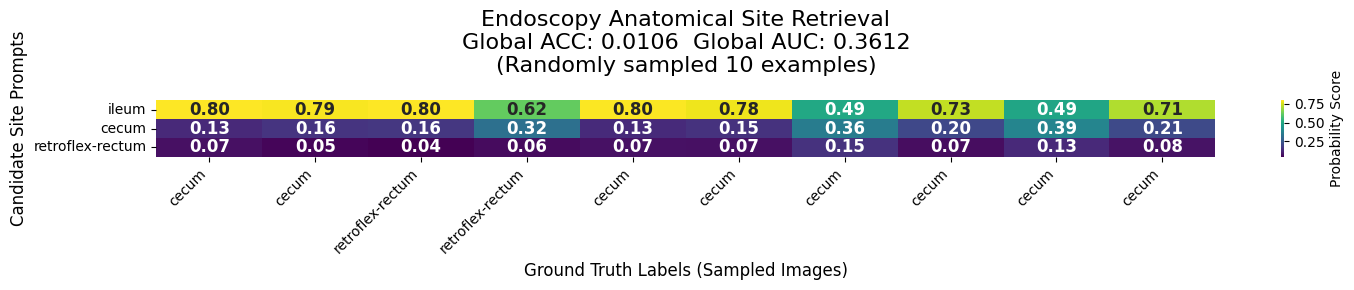

[0.4199, 0.3935, 0.2701]

In [260]:
sample_texts = site_prompts_lower
sample_image_paths = sample_image_lower
class_names = class_names_lower
print(mode)
image_features_all, sample_names = [], []

if mode == 'clip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer=None, stack=False)
  similarity_matrix_all = []
  for imgs, img_count, paths in zip(imgs_batch, img_counts, sample_image_paths):
    with torch.no_grad():
      sample_names.append(paths[0].split('/')[-2])

      inputs = processor(text=sample_texts, images=imgs, return_tensors="pt", padding=True).to('cuda')
      outputs = model_open_clip(**inputs)
      logits_per_image = outputs.logits_per_image
      similarity_matrix_all.append(logits_per_image)

  similarity_matrix_all = torch.cat(similarity_matrix_all, dim=0)

elif mode == 'biomedclip':
  similarity_matrix_all = []
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer, stack=True)
  for imgs, img_count, paths, label in tqdm(zip(imgs_batch, img_counts, sample_image_paths, labels)):
    with torch.no_grad():
      image_features, text_features, logit_scale = model_open_clip(imgs.cuda(), texts_batch.cuda())
      sample_names.append(paths[0].split('/')[-2])
      logits = (logit_scale * image_features @ text_features.t()).detach().softmax(dim=-1)
      similarity_matrix_all.append(logits)
  similarity_matrix_all = torch.cat(similarity_matrix_all, dim=0)

res = visualize_similarity_with_metrics(
    similarity_matrix=similarity_matrix_all, 
    image_labels=sample_names, 
    text_labels=class_names,
    title="Endoscopy Anatomical Site Retrieval",
)

[float(f"{res[-1][k]['auc']:.4f}") for k in res[-1] ]

In [261]:
# in retroflexion mode.
site_prompts_dict = {
    "z-line": "An image of z-line",
    "retroflex-stomach": "An image of fundus.",
    "pylorus": "An image of pylorus."
}

class_names_upper = [k for k in site_prompts_dict]
site_prompts_upper = [site_prompts_dict[k] for k in site_prompts_dict]

sample_image_upper = get_random_endoscopy_samples(base_dir, num_per_class=5, mode='upper', seed=42, get_all=True)

已从 upper 消化道路径中选取了 2695 个样本。



Class Name           | ACC (Recall) | AUC (OvR) 
--------------------------------------------------
z-line               | 0.0000       | 0.4659    
retroflex-stomach    | 0.8390       | 0.5435    
pylorus              | 0.1912       | 0.4620    
total                | 0.3087       | 0.4905    


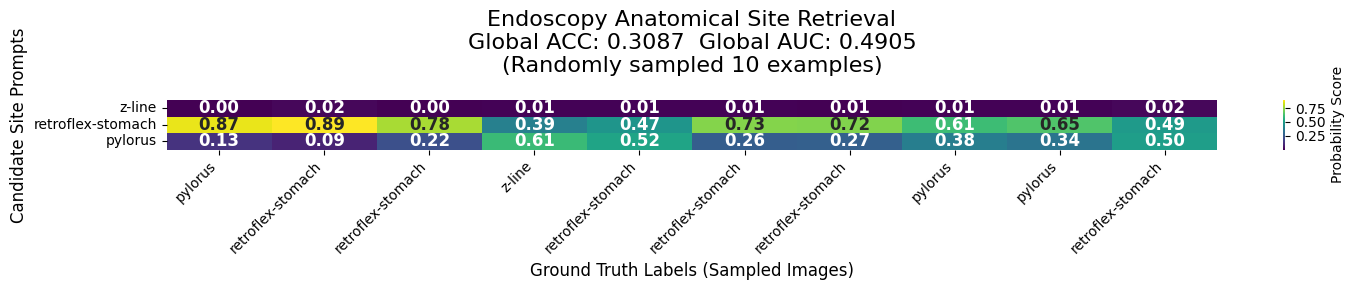

[0.4659, 0.5435, 0.462]

In [262]:
sample_texts = site_prompts_upper
sample_image_paths = sample_image_upper
class_names = class_names_upper
print(mode)
image_features_all, sample_names = [], []

if mode == 'clip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer=None, stack=False)
  similarity_matrix_all = []
  for imgs, img_count, paths in zip(imgs_batch, img_counts, sample_image_paths):
    with torch.no_grad():
      sample_names.append(paths[0].split('/')[-2])

      inputs = processor(text=sample_texts, images=imgs, return_tensors="pt", padding=True).to('cuda')
      outputs = model_open_clip(**inputs)
      logits_per_image = outputs.logits_per_image # this is the image-text similarity score
      similarity_matrix_all.append(logits_per_image)

  similarity_matrix_all = torch.cat(similarity_matrix_all, dim=0)

elif mode == 'biomedclip':
  similarity_matrix_all = []
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer, stack=True)
  for imgs, img_count, paths, label in tqdm(zip(imgs_batch, img_counts, sample_image_paths, labels)):
    with torch.no_grad():
      image_features, text_features, logit_scale = model_open_clip(imgs.cuda(), texts_batch.cuda())
      sample_names.append(paths[0].split('/')[-2])
      logits = (logit_scale * image_features @ text_features.t()).detach().softmax(dim=-1)
      similarity_matrix_all.append(logits)
  similarity_matrix_all = torch.cat(similarity_matrix_all, dim=0)

res = visualize_similarity_with_metrics(
    similarity_matrix=similarity_matrix_all, 
    image_labels=sample_names, 
    text_labels=class_names,
    title="Endoscopy Anatomical Site Retrieval",
)

[float(f"{res[-1][k]['auc']:.4f}") for k in res[-1] ]

已从 both 消化道路径中选取了 12 个样本。


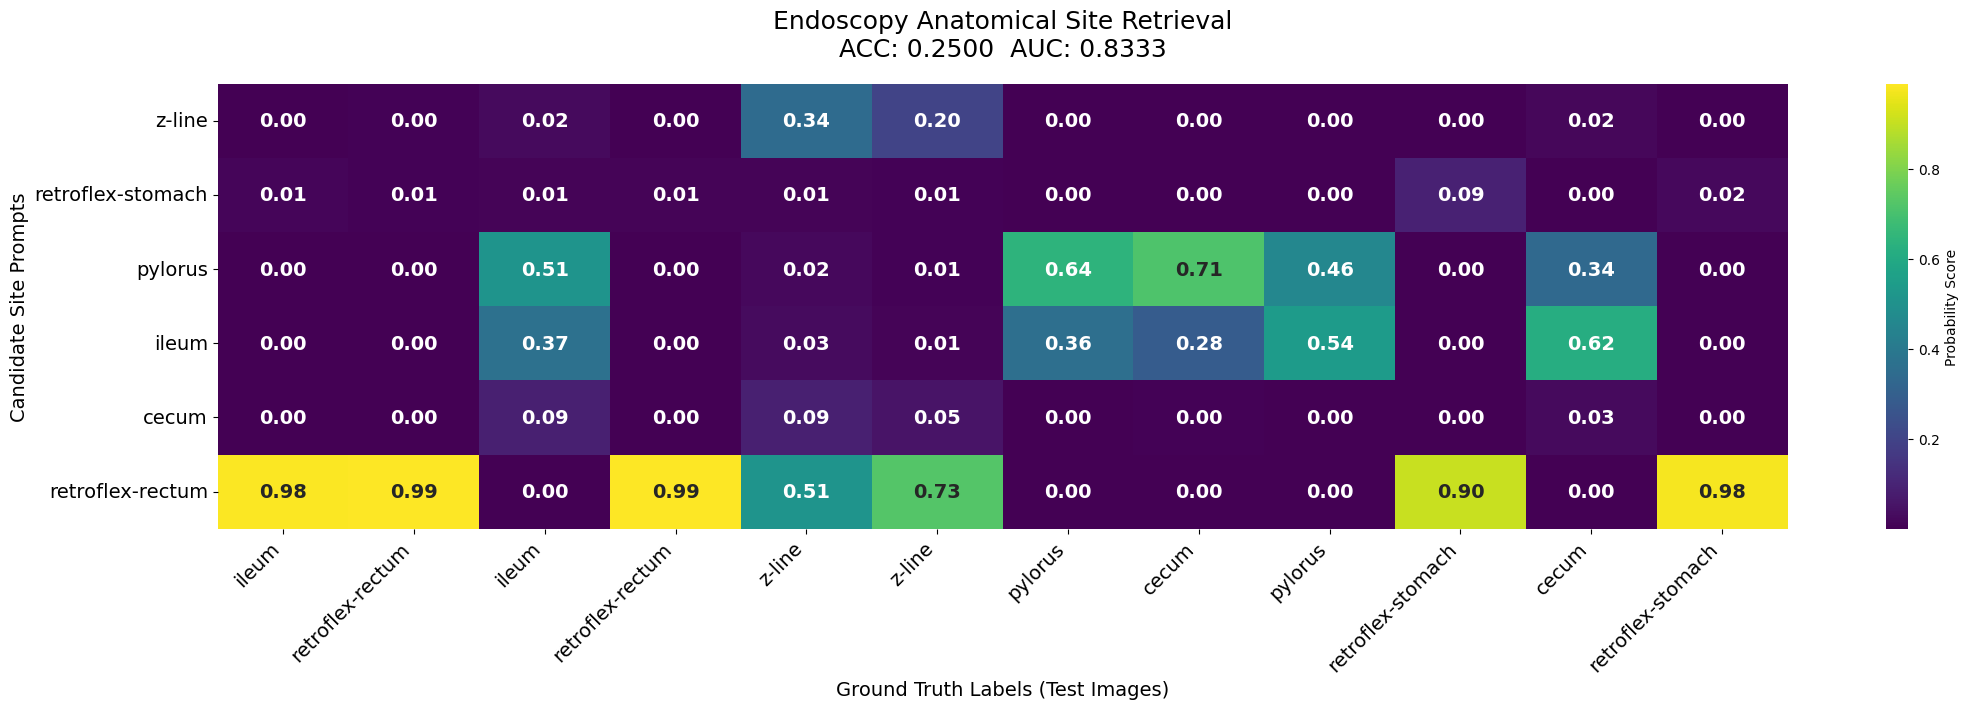

(0.25, 0.8333333333333334)

In [212]:

# 4. 获取全部
all_samples = get_random_endoscopy_samples(base_dir, num_per_class=2, mode='both', seed=42)
class_names = class_names_upper + class_names_lower
sample_texts = site_prompts_upper + site_prompts_lower

sample_image_paths = all_samples

imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer)
image_features_all, sample_names = [], []
for imgs, img_count, paths in zip(imgs_batch, img_counts, sample_image_paths):
  with torch.no_grad():
    if img_count == 1:
      image_features = model.get_local_image_features(imgs.unsqueeze(0).cuda())
    elif img_count > 1:
      image_features = model.get_global_image_features(imgs.cuda())
  text_features = model.get_text_features(texts_batch.cuda())
  image_features_all.append(image_features)
  # similarity_matrix[i, j] 表示第 i 个图像样本与第 j 个文本的匹配得分
  similarity_matrix = torch.matmul(image_features, text_features.T) * model.model.logit_scale.exp()
  similarity_matrix = torch.softmax(similarity_matrix, dim=-1).cpu().detach().numpy()
  val, index = np.max(similarity_matrix, axis=-1), np.argmax(similarity_matrix, axis=-1)

  sample_names.append(paths[0].split('/')[-2])

image_features_all = torch.cat(image_features_all, dim=0)
similarity_matrix_all = torch.matmul(image_features_all, text_features.T) * model.model.logit_scale.exp()

visualize_similarity_with_metrics(
    similarity_matrix=similarity_matrix_all, 
    image_labels=sample_names, 
    text_labels=class_names,
    title="Endoscopy Anatomical Site Retrieval",
)

# polypdiag

In [248]:
import cv2
from PIL import Image
def sample_video_frames(video_path, n_frames, seed=None):
  """
  从视频中采样 n_frames 帧。
  - 若 n_frames <= 总帧数：均匀采样（含首尾）。
  - 若 n_frames > 总帧数：取全部帧 + 随机重复部分帧至 n_frames。

  参数:
    video_path (str): 视频文件路径。
    n_frames (int): 要采样的帧数。
    seed (int, optional): 随机种子，用于可复现性。

  返回:
    List[PIL.Image.Image]: 长度为 n_frames 的图像列表。
  """
  if seed is not None:
    random.seed(seed)
  
  cap = cv2.VideoCapture(video_path)
  if not cap.isOpened():
    raise IOError(f"无法打开视频文件: {video_path}")
  
  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  if total_frames == 0:
    raise ValueError("视频文件帧数为0，可能是损坏或不支持的格式。")
  
  # 读取所有帧（避免多次 set + read，效率更高）
  all_frames = []
  while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(frame_rgb)
    all_frames.append(pil_image)
  
  cap.release()
  
  # 如果实际读取的帧数和 CAP_PROP_FRAME_COUNT 不一致，以实际为准
  actual_total = len(all_frames)
  if actual_total == 0:
    raise ValueError("未能从视频中读取任何帧。")

  if n_frames <= actual_total:
    # 均匀采样（含首尾）
    indices = [int(i * (actual_total - 1) / (n_frames - 1)) for i in range(n_frames)] if n_frames > 1 else [0]
    sampled_frames = [all_frames[i] for i in indices]
  else:
    # 全部帧 + 随机重复
    sampled_frames = all_frames.copy()
    # 随机选择 (n_frames - actual_total) 个帧进行重复
    num_to_repeat = n_frames - actual_total
    repeated = random.choices(all_frames, k=num_to_repeat)  # 可重复采样
    sampled_frames.extend(repeated)
  
  return sampled_frames


In [263]:
split_file = '/mnt/data/xujianwei.xjw/workspace/Endo-FM/data/downstream/PolypDiag/splits/val.txt'
video_root = '/mnt/data/xujianwei.xjw/workspace/Endo-FM/data/downstream/PolypDiag/videos/'
videos, labels = [], []
with open(split_file, "r") as f:
    for clip_idx, path_label in enumerate(f.read().splitlines()):
        assert (
                len(path_label.split(','))
                == 2
        )
        path, label = path_label.split(',')
        videos.append(os.path.join(video_root, path))
        labels.append(int(label))

sample_image_paths = []
for video_path in videos:
  sample_image_paths.append(sample_video_frames(video_path, n_frames=16))

In [264]:

site_prompts_dict = {
    "normal": "Endoscopic findings of other abnormalities.",
    "polyp": "An endoscopic image of a small polypoid lesion or mucosal elevation (0.1-0.5cm).",
} # auc: 0.8 with Mean-pooling

# site_prompts_dict = {
#     # 合并了尺寸、形状、表面特征和临床动作
#     "polyp": (
#         "Endoscopic image of a colonic polypoid elevation or small mucosal protrusion (0.3-0.5 cm) "
#         "with a smooth or slightly depressed surface, potentially identified for biopsy forceps removal."
#     ),
    
#     # 合并了正常纹理、萎缩、平坦溃疡以及“非隆起”这一核心特征
#     "non_polyp": (
#         "Endoscopic image showing normal mucosa with clear vascularity, or non-polypoid findings "
#         "such as mucosal atrophy and flat ulcerated areas, with no protruding or raised lesions."
#     )
# }


# site_prompts_dict = {
#     # 描述息肉的视觉特征：凸起、颜色异常、质地
#     "polyp": "An endoscopic image of a colonic polyp, showing a protruding mucosal lesion.",
    
#     # 描述正常的视觉特征：平滑的粘膜、清晰的血管
#     "normal": "Normal colonic mucosa with smooth surface and clear vascular patterns, no lesions.",
# } # auc: 0.6 with Mean-pooling

# site_prompts_dict = {
#     "normal": "Normal and healthy endoscopic mucosa with clear vascular patterns and no signs of lesions.",
#     "polyp": "An endoscopic image of a small polypoid lesion or mucosal elevation (0.3-0.5cm) with a smooth surface.",
#     "other_lesions": "Endoscopic findings of non-polypoid abnormalities, such as flat ulcers, mucosal atrophy, or diffuse inflammation."
# }

class_names = [k for k in site_prompts_dict]
sample_texts = [site_prompts_dict[k] for k in site_prompts_dict]

In [266]:
print('model:', mode)
if mode == 'clip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer=None, stack=False)
elif mode == 'biomedclip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer, stack=False)
print(len(imgs_batch), sum(img_counts))

model: clip
80 1280


In [290]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score
from tqdm import tqdm

def video_level_prediction(similarity_probs, k=5):
    """
    Args:
        similarity_probs: [T, 2] 经过 softmax 后的概率
        k: 取前 k 帧最像息肉的概率
    Returns:
        final_polyp_score: 视频属于息肉类的得分
    """
    # 假设第 0 列是 polyp
    polyp_probs = similarity_probs[:, 1]
    
    # 取概率最高的 K 帧求平均，作为该视频为“息肉”的置信度
    actual_k = min(k, polyp_probs.shape[0])
    topk_indices = np.argsort(polyp_probs)[-actual_k:]
    final_polyp_score = np.mean(polyp_probs[topk_indices])
    
    return final_polyp_score

# --- 准备容器 ---
all_video_scores = []  # 存储每个视频是 polyp 的概率
all_true_labels = []   # 存储真实标签
K = 100

# 1. 预先提取文本特征 (只需一次)
model.eval()
if mode == 'biomedclip':
  for imgs, img_count, paths, label in tqdm(zip(imgs_batch, img_counts, sample_image_paths, labels)):
      with torch.no_grad():
        image_features, text_features, logit_scale = model_open_clip(imgs.cuda(), texts_batch.cuda())
        logits = (logit_scale * image_features @ text_features.t()).detach().softmax(dim=-1)
 
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        # 视频级聚合：得到该视频是 Polyp 的综合得分
        video_polyp_score = video_level_prediction(probs, k=K)
    
        all_video_scores.append(video_polyp_score)
        all_true_labels.append(label)
elif mode == 'clip':
  for imgs, img_count, paths, label in zip(imgs_batch, img_counts, sample_image_paths, labels):
    with torch.no_grad():

      inputs = processor(text=sample_texts, images=imgs, return_tensors="pt", padding=True).to('cuda')
      outputs = model_open_clip(**inputs)
      logits = outputs.logits_per_image
      probs = torch.softmax(logits, dim=-1).cpu().numpy()
      # 视频级聚合：得到该视频是 Polyp 的综合得分
      video_polyp_score = video_level_prediction(probs, k=K)
  
      all_video_scores.append(video_polyp_score)
      all_true_labels.append(label)

In [298]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, f1_score
y_scores = np.array(all_video_scores)
y_true = np.array(all_true_labels) # 1-Polyp, 0-Normal

y_true_binary = np.where(y_true == 1, 1, 0) 
f1_best, thres_best = 0, 0
for thres in np.arange(0.988, 1.0, 0.01):
  # thres = 0.5
  y_pred = (y_scores > thres).astype(int)

  f1 = f1_score(y_true_binary, y_pred)
  if f1 > f1_best:
    f1_best = f1
    thres_best = thres
    auc = roc_auc_score(y_true_binary, y_scores)
    acc = accuracy_score(y_true_binary, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred).ravel()
    sen = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity / Recall
    spe = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity
    pre = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision

print(f"=== Threshold: {thres_best:.2f} ===")
print(f"=== Video-Level Evaluation (N={len(y_true)}, K={K}) ===")
print(f"AUC: {auc:.4f}")
print(f"ACC: {acc:.4f}")
print(f"SEN (Sensitivity/Recall): {sen:.4f}")
print(f"SPE (Specificity): {spe:.4f}")
print(f"PRE (Precision): {pre:.4f}")
print(f"F1: {f1_best:.4f}")


=== Threshold: 0.99 ===
=== Video-Level Evaluation (N=80, K=100) ===
AUC: 0.5458
ACC: 0.4500
SEN (Sensitivity/Recall): 0.4000
SPE (Specificity): 0.6000
PRE (Precision): 0.7500
F1: 0.5217


In [ ]:
sample_texts = site_prompts_upper
sample_image_paths = sample_image_upper
class_names = class_names_upper

image_features_all, sample_names = [], []
print('model:', mode)
if mode == 'clip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer=None, stack=False)
  similarity_matrix_all = []
  for imgs, img_count, paths in zip(imgs_batch, img_counts, sample_image_paths):
    with torch.no_grad():
      sample_names.append(paths[0].split('/')[-2])

      inputs = processor(text=sample_texts, images=imgs, return_tensors="pt", padding=True).to('cuda')
      outputs = model_open_clip(**inputs)
      logits_per_image = outputs.logits_per_image # this is the image-text similarity score
      similarity_matrix_all.append(logits_per_image)

  similarity_matrix_all = torch.cat(similarity_matrix_all, dim=0)
elif mode == 'biomedclip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, sample_texts, transform, tokenizer, stack=True)
  
  with torch.no_grad():
    image_features, text_features, logit_scale = model_open_clip(imgs_batch.cuda(), texts_batch.cuda())
    logits = (logit_scale * image_features @ text_features.t()).detach().softmax(dim=-1)
    similarity_matrix_all = logits.cpu().numpy()

  for imgs, img_count, paths in zip(imgs_batch, img_counts, sample_image_paths):
      sample_names.append(paths[0].split('/')[-2])

visualize_similarity_with_metrics(
    similarity_matrix=similarity_matrix_all, 
    image_labels=sample_names, 
    text_labels=class_names,
    title="Endoscopy Anatomical Site Retrieval",
)

# LIMUC

In [253]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

def compute_single_card_metrics(all_scores, all_true_labels, num_classes=2):
    """
    针对单卡测试结果计算指标
    
    Args:
        all_scores: [N, C] 的 Tensor 或 array，表示 Softmax 后的概率 (0~1)
        all_true_labels: [N] 的 Tensor 或 array，表示真实标签索引 (0, 1, ...)
        num_classes: 类别总数 (二分类为 2, MES 为 4)
        
    Returns:
        acc, prec, rec, spe, auc
    """
    # 1. 统一转换为 numpy 格式
    if torch.is_tensor(all_scores):
        all_probs = all_scores.cpu().detach().numpy()
    else:
        all_probs = all_scores
        
    if torch.is_tensor(all_true_labels):
        all_targets = all_true_labels.cpu().detach().numpy()
    else:
        all_targets = all_true_labels

    # 2. 获取预测索引 [N]
    all_preds = np.argmax(all_probs, axis=1)

    # 3. 计算 Accuracy (准确率)
    acc = accuracy_score(all_targets, all_preds)
    
    # 4. 计算 Precision (精确率) 和 Recall (召回率/敏感度)
    # 对于二分类，常用 'binary'；对于多分类，使用 'macro'
    avg_mode = 'binary' if num_classes == 2 else 'macro'
    prec = precision_score(all_targets, all_preds, average=avg_mode, zero_division=0)
    rec = recall_score(all_targets, all_preds, average=avg_mode, zero_division=0)
    
    # 5. 计算 AUC (曲线下面积)
    try:
        if num_classes == 2:
            # 二分类时，通常取正类（索引1）的得分
            # 如果你的正类是 0 (Polyp)，则需传入 all_probs[:, 0] 并反转 labels
            auc = roc_auc_score(all_targets, all_probs[:, 1])
        else:
            # 多分类使用 One-vs-One 策略
            auc = roc_auc_score(all_targets, all_probs, multi_class='ovo', average='macro')
    except Exception as e:
        print(f"AUC 计算失败: {e}")
        auc = 0.0

    # 6. 计算 Specificity (特异度)
    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))
    if num_classes == 2:
        # 二分类逻辑: TN / (TN + FP)
        # 注意：这里假设 0 是负类(Normal)，1 是正类(Polyp/Disease)
        tn, fp, fn, tp = cm.ravel()
        spe = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        # 多分类逻辑: 计算每一类作为负例时的特异度再取均值 (参考你提供的代码)
        spec_list = []
        for i in range(num_classes):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
            spec_list.append(specificity_i)
        spe = np.mean(spec_list)

    return acc, prec, rec, spe, auc


In [254]:
limuc_root = '/mnt/data/xujianwei.xjw/workspace/Endo-FM/data/downstream/LIMUC/test_set'
classes = ['Mayo 0', 'Mayo 1', 'Mayo 2', 'Mayo 3']
images, labels = [], []
for folder in classes:
  folder_path = os.path.join(limuc_root, folder)
  for file_name in os.listdir(folder_path):
    file_path = os.path.join(folder_path, file_name)
    images.append(file_path)
    labels.append(int(folder.split(' ')[-1]))
random.shuffle(images)
labels = [int(x.split('/')[-2].split(' ')[-1]) for x in images]

# combined = list(zip(images, labels))
# shuffled = np.random.permutation(combined)
# sample_image_paths, labels = zip(*shuffled)

sample_image_paths = [[x] for x in images]

In [255]:
print('model:', mode)
if mode == 'clip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, None, transform, tokenizer=None, stack=False)
elif mode == 'biomedclip':
  imgs_batch, texts_batch, img_counts = process_data(sample_image_paths, None, transform, tokenizer, stack=False)
print(len(imgs_batch), sum(img_counts))

model: biomedclip
1686 1686


In [256]:
print(len(imgs_batch), sum(img_counts))

1686 1686


In [251]:
# mes_prompts_dict = {
#     # 类别 0: MES 0 (完全正常/缓解)
#     # 模仿语料：smooth and soft, clear vascular pattern, no abnormalities
#     "Normal_Remission (MES 0)": (
#         "Mucosa: The mucosa is smooth and soft, with a clear and distinct vascular pattern. "
#         "The vascular network is sharply visible. No signs of congestion, edema, or erosions. "
#         "No abnormalities observed, and no ulcers or bleeding are present."
#     ),
    
#     # 类别 1: MES 1/2/3 (活动期炎症)
#     # 模仿语料：mosaic of red and white, hyperemia, erosions, ulcers
#     # 涵盖了从血管模糊(1)到消失(2)到出血(3)的所有描述
#     "Active_Inflammation (MES 1-3)": (
#         "Mucosa: The mucosa shows an abnormal mixed red-and-white mottled appearance, "
#         "with mucosal congestion or hyperemia. The vascular pattern is blurred, faintly visible, or completely absent. "
#         "There are findings of scattered superficial erosions, mucosal friability, or prominent ulcerations with bleeding."
#     )
# }

mes_prompts_dict = {
    # Grade 0: 正常或静止期
    "MES_0": (
        "Mayo Endoscopic Score 0: Normal or inactive ulcerative colitis. "
        "The mucosa shows a clear and distinct vascular pattern, smooth surface, and no signs of inflammation."
    ),
    
    # Grade 1: 轻度 (血管纹理模糊、红斑)
    "MES_1": (
        "Mayo Endoscopic Score 1: Mild ulcerative colitis activity. "
        "Characterized by erythema (redness) and a decreased vascular pattern. "
        "The mucosa looks blurred but has no spontaneous bleeding."
    ),
    
    # Grade 2: 中度 (血管纹理消失、糜烂、脆性增加)
    "MES_2": (
        "Mayo Endoscopic Score 2: Moderate ulcerative colitis activity. "
        "Marked erythema with a completely absent vascular pattern. "
        "Presence of mucosal friability (bleeds when touched) and small erosions."
    ),
    
    # Grade 3: 重度 (自发出血、大溃疡)
    "MES_3": (
        "Mayo Endoscopic Score 3: Severe ulcerative colitis activity. "
        "Prominent ulcerations and spontaneous bleeding are visible. "
        "The mucosal surface is heavily damaged with significant inflammatory exudate."
    )
}

class_names = [k for k in mes_prompts_dict]
sample_texts = [mes_prompts_dict[k] for k in mes_prompts_dict]
texts_batch = tokenizer(sample_texts)

In [168]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score
from tqdm import tqdm

# --- 准备容器 ---
all_video_scores = []  # 存储每个视频是 polyp 的概率
all_true_labels = []   # 存储真实标签
K = 100


# 1. 预先提取文本特征 (只需一次)
model.eval()
if mode == 'biomedclip':
  for imgs, img_count, paths, label in tqdm(zip(imgs_batch, img_counts, sample_image_paths, labels)):
      with torch.no_grad():
        image_features, text_features, logit_scale = model_open_clip(imgs.cuda(), texts_batch.cuda())
        logits = (logit_scale * image_features @ text_features.t()).detach().softmax(dim=-1)
 
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_video_scores.append(probs.squeeze())

        # label_true = 0 if label <= 1 else 1
        label_true = label
        # label_true = 0 if label <= 0 else 1
        all_true_labels.append(label_true)

elif mode == 'clip':
  for imgs, img_count, paths in zip(imgs_batch, img_counts, sample_image_paths):
    with torch.no_grad():
      sample_names.append(paths[0].split('/')[-2])

      inputs = processor(text=sample_texts, images=imgs, return_tensors="pt", padding=True).to('cuda')
      outputs = model_open_clip(**inputs)
      logits = outputs.logits_per_image
      probs = torch.softmax(logits, dim=-1).cpu().numpy()
      all_video_scores.append(probs.squeeze())

      # label_true = 0 if label <= 1 else 1
      label_true = label
      # label_true = 0 if label <= 0 else 1
      all_true_labels.append(label_true)

all_video_scores = np.array(all_video_scores)

1686it [00:31, 52.74it/s]


In [169]:
acc, pre, sen, spe, auc = compute_single_card_metrics(all_video_scores, all_true_labels, num_classes=all_video_scores.shape[1])
print(f"ACC: {acc:.4f}, PRE: {pre:.4f}, SEN: {sen:.4f}, SPE: {spe:.4f}, AUC: {auc:.4f}")


ACC: 0.4353, PRE: 0.4188, SEN: 0.4317, SPE: 0.7849, AUC: 0.7324


In [170]:
all_video_scores.shape

(1686, 4)

In [171]:
print(all_video_scores[:10])
print(all_true_labels[:10])

[[0.3851712  0.23677392 0.19170238 0.18635252]
 [0.41409642 0.2134501  0.18914063 0.18331283]
 [0.22746715 0.34320268 0.23809159 0.19123857]
 [0.26643804 0.34840828 0.19650348 0.18865019]
 [0.2700558  0.314966   0.22283599 0.19214223]
 [0.33035085 0.27678898 0.20292212 0.18993805]
 [0.38857046 0.23359977 0.19204204 0.18578774]
 [0.24149285 0.37957117 0.1924019  0.18653403]
 [0.2815871  0.3017826  0.21636212 0.20026821]
 [0.32165948 0.28957552 0.19907784 0.18968716]]
[1, 2, 0, 0, 1, 0, 0, 0, 0, 1]
